In [1]:
import ipyparallel as ipp

#cluster = ipp.Cluster.from_file("/home/peter/.ipython/profile_mpi/security/cluster-mpi2.json")
#rc = cluster.connect_client_sync()
#rc
cluster = ipp.Cluster(engines='mpi', n=4)
rc = cluster.start_and_connect_sync(activate=True)

Starting 4 engines with <class 'ipyparallel.cluster.launcher.MPIEngineSetLauncher'>
100%|██████████| 4/4 [00:05<00:00,  1.42s/engine]


In [2]:
#%%px 
import yt
import numpy as np
#from yt.mods import *
from yt.frontends.boxlib.api import NyxDataset, AMReXDataset
from yt.data_objects.time_series import DatasetSeries
import matplotlib.pyplot as plt
from matplotlib import rc_context
from matplotlib.animation import FuncAnimation
from IPython import display
from matplotlib.figure import Figure
import time

In [3]:
%%px 
import yt
yt.enable_parallelism()
# run the mpi_example function on all engines in parallel
#r = view.apply_sync(yt.enable_parallelism())
#yt.enable_parallelism()

[stderr:0] yt : [INFO     ] 2025-07-17 16:20:26,737 Global parallel computation enabled: 0 / 4


[stderr:2] yt : [INFO     ] 2025-07-17 16:20:26,737 Global parallel computation enabled: 2 / 4


[stderr:1] yt : [INFO     ] 2025-07-17 16:20:26,737 Global parallel computation enabled: 1 / 4


[stderr:3] yt : [INFO     ] 2025-07-17 16:20:26,737 Global parallel computation enabled: 3 / 4


Out[3:1]: True

Out[0:1]: True

Out[1:1]: True

Out[2:1]: True

In [4]:
#%%px
class AMReXDatasetSeries(DatasetSeries):
    _dataset_cls = AMReXDataset

In [5]:
#%%px
path = "../Outputs/plt0????"
dsLoad = AMReXDatasetSeries(path)

In [6]:
#%%px
ds = []
for data in dsLoad:
    ds.append(data)

yt : [INFO     ] 2025-07-17 16:20:26,786 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-07-17 16:20:26,786 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2025-07-17 16:20:26,787 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-07-17 16:20:26,787 Parameters: domain_right_edge         = [20. 20. 20.]
yt : [INFO     ] 2025-07-17 16:20:26,808 Parameters: current_time              = 2.5
yt : [INFO     ] 2025-07-17 16:20:26,808 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2025-07-17 16:20:26,808 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-07-17 16:20:26,809 Parameters: domain_right_edge         = [20. 20. 20.]
yt : [INFO     ] 2025-07-17 16:20:26,829 Parameters: current_time              = 4.99999999999999
yt : [INFO     ] 2025-07-17 16:20:26,829 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2025-07-17 16:20:26,830 Parameters: domain_left_edge    

In [7]:
#%%px
def _relE (field, data):
    av = data.ds.all_data().quantities.weighted_average_quantity("Edens", weight = ("index", "ones"))
    return data["Edens"]/av
for data in ds:
    data.add_field(("boxlib","EdensRel"), function=_relE, sampling_type="local", units="dimensionless",force_override=True)

In [8]:
#%%px
tmpData = ds[4]
scOut = yt.create_scene(tmpData, ("boxlib", "EdensRel"))#, lens_type="perspective", )
scOut.annotate_domain(tmpData, color=[1, 1, 1, 0.01])
#scOut.annotate_grids(tmpData, alpha=0.0005)
sourceOut = scOut[0]
sourceOut.set_field(("boxlib", "EdensRel"))
sourceOut.set_log(False)
sourceOut.tfh.gray_opacity = False
#source.tfh.set_bounds((1e-15, 1e-6))
sourceOut.tfh.set_log(False)

mnOut, mxOut = tmpData.all_data().quantities.extrema("EdensRel")
if (mnOut < 0):
    mnOut = -mnOut
boundsOut = (mnOut, mxOut)

# Since this rendering is done in log space, the transfer function needs
# to be specified in log space.
#tfOut = yt.ColorTransferFunction(np.log10(boundsOut))
tfOut = yt.ColorTransferFunction(boundsOut)

tfOut.add_layers(5, colormap="arbre")

sourceOut.tfh.tf = tfOut
sourceOut.tfh.bounds = boundsOut

scOut.camera.zoom(0.9)
#source.tfh.plot("transfer_function.png", profile_field=("boxlib", "Edens"))
test = scOut.render()
#sc.show(sigma_clip=0.9)

yt : [INFO     ] 2025-07-17 16:20:32,884 Rendering scene (Can take a while).
yt : [INFO     ] 2025-07-17 16:20:32,887 Creating volume


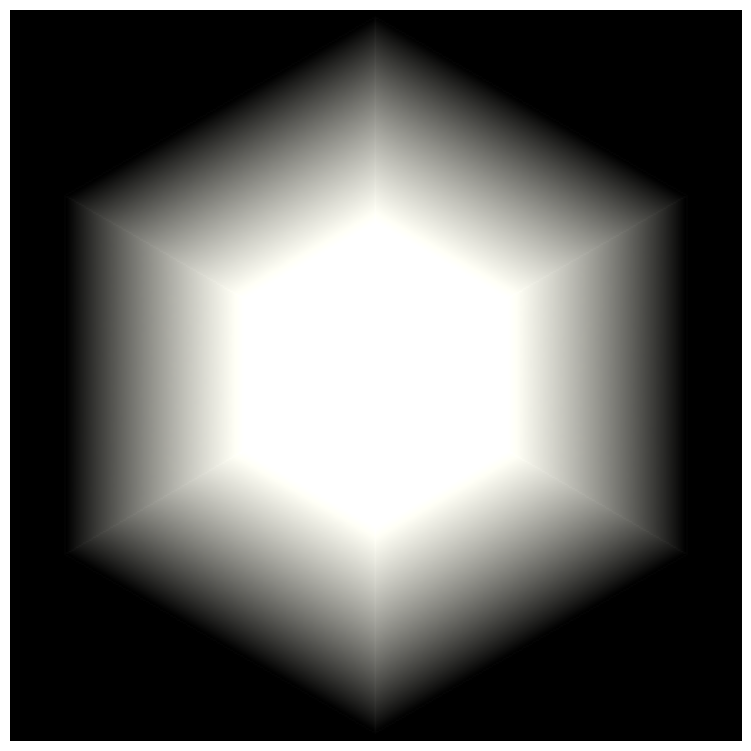

In [9]:
#%%px
# Hacky, but I think this is the only way. This is basically the content of scene.save
sigma_clip=1

#temp = test

shape = test.shape
#fig = Figure((shape[0] / 100.0, shape[1] / 100.0))
fig = plt.figure()
fig.set(dpi = 100)
fig.set_size_inches((shape[0] / 70.0, shape[1] / 70.0))
canvas = fig.canvas #yt.visualization._commons.get_canvas(fig, yt.visualization._commons.validate_image_name("Volume Render"))

ax = fig.add_axes([0, 0, 1, 1])
ax.set_axis_off()
nz = test[:, :, :3][test[:, :, :3].nonzero()]
max_val = nz.mean() + sigma_clip * nz.std()
alpha = 255 * test[:, :, 3].astype("uint8")
temp = np.clip(test[:, :, :3] / max_val, 0.0, 1.0) * 255
temp = np.concatenate([temp.astype("uint8"), alpha[..., None]], axis=-1)
temp = np.rot90(temp)
ax.imshow(temp, origin="lower")

In [10]:
for data in ds:
    mn, mx = data.all_data().quantities.extrema("EdensRel")
    print ("Min = " + str(mn) + ", Max = " + str(mx))

Min = 0.9999011172392112 dimensionless, Max = 1.0004954483363322 dimensionless
Min = 0.9970799033748543 dimensionless, Max = 1.003843828485448 dimensionless
Min = 0.9949546713031104 dimensionless, Max = 1.0060081003271941 dimensionless
Min = 0.9934761011691619 dimensionless, Max = 1.0071578327970392 dimensionless
Min = 0.9863165878896722 dimensionless, Max = 1.0120153182650244 dimensionless
Min = 0.9766988352126559 dimensionless, Max = 1.0260978478100304 dimensionless
Min = 0.9974011346790302 dimensionless, Max = 1.0029784510148376 dimensionless
Min = 0.9889495883942008 dimensionless, Max = 1.0106864403213123 dimensionless
Min = 0.9830020964086843 dimensionless, Max = 1.0183108846205275 dimensionless
Min = 0.9946177735364461 dimensionless, Max = 1.0059852959997744 dimensionless
Min = 0.9810537384952994 dimensionless, Max = 1.0194059566119704 dimensionless
Min = 0.9945601558827432 dimensionless, Max = 1.0054298573435039 dimensionless
Min = 0.9799081717979593 dimensionless, Max = 1.02022

In [11]:
renders = []
for data in ds:
#for i in range(len(ds) - 2, len(ds)):
#    data = ds[i]
        
    sc = yt.create_scene(data, ("boxlib", "EdensRel"))#, lens_type="perspective", )
    sc.annotate_domain(data, color=[1, 1, 1, 0.01])
    sc.annotate_grids(data, alpha=0.01)
    source = sc[0]
    source.set_field(("boxlib", "EdensRel"))
    source.set_log(True)
    #source.set_log(False)
    source.tfh.gray_opacity = False
    source.tfh.set_log(True)
    #source.tfh.set_log(False)

    av = data.all_data().quantities.weighted_average_quantity("Edens", weight = ("index", "ones"))
    mn, mx = data.all_data().quantities.extrema("EdensRel")
    
    #print ("Min = " + str(mn) + ", Max = " + str(mx))
#    if (mnI < 0):
#        mn = -mn
    #   1e-20
    #mn = 10*av
    mn = 1
    if mn > mx:
        mx = 2*mn
    bounds = (mn, mx)
    #print(bounds)
    #bounds = (2*mx,10*mx)

    # Since this rendering is done in log space, the transfer function needs
    # to be specified in log space.
    tf = yt.ColorTransferFunction(np.log10(bounds))
    #tf = yt.ColorTransferFunction(bounds)

    tf.add_layers(5, colormap="arbre")

    source.tfh.tf = tf
    source.tfh.bounds = bounds

    sc.camera.zoom(0.9)
#source.tfh.plot("transfer_function.png", profile_field=("boxlib", "Edens"))
    renders.append(sc.render())
    #sc.show(sigma_clip=0.7)

/home/lsou343/.local/lib/python3.10/site-packages/unyt/array.py:1949: RuntimeWarning: invalid value encountered in divide
  out_arr = func(
/home/lsou343/.local/lib/python3.10/site-packages/yt/visualization/image_writer.py:269: RuntimeWarning: invalid value encountered in cast
  mapped = np.dstack([(np.interp(buff, x, v) * 255).astype("uint8") for v in lut])
yt : [INFO     ] 2025-07-17 16:20:36,376 Rendering scene (Can take a while).
yt : [INFO     ] 2025-07-17 16:20:36,381 Creating volume
yt : [INFO     ] 2025-07-17 16:20:36,932 Rendering scene (Can take a while).
yt : [INFO     ] 2025-07-17 16:20:36,936 Creating volume
yt : [INFO     ] 2025-07-17 16:20:37,387 Rendering scene (Can take a while).
yt : [INFO     ] 2025-07-17 16:20:37,391 Creating volume
yt : [INFO     ] 2025-07-17 16:20:37,829 Rendering scene (Can take a while).
yt : [INFO     ] 2025-07-17 16:20:37,833 Creating volume
yt : [INFO     ] 2025-07-17 16:20:38,273 Rendering scene (Can take a while).
yt : [INFO     ] 2025-07-1

In [12]:
def animate(i):

    sigma_clip = 0.7
    
    nz = renders[i][:, :, :3][renders[i][:, :, :3].nonzero()]
    max_val = nz.mean() + sigma_clip * nz.std()
    #max_val = 5.*nz.mean()
    alpha = 255 * renders[i][:, :, 3].astype("uint8")
    temp = np.clip(renders[i][:, :, :3] / max_val, 0.0, 1.0) * 255
    #test = np.clip(renders[i][:, :, :3] / max_val, 0.0, None) * 255
    temp = np.concatenate([temp.astype("uint8"), alpha[..., None]], axis=-1)
    temp = np.rot90(temp)
    ax.imshow(temp, origin="lower")

In [13]:
#for i in range(len(ds)):
#    print("i = " + str(i))
#    animate(i)

In [14]:
animation = FuncAnimation(fig, animate, frames=len(renders), interval = 400)
animation.save('animation 3D 128-32 TMI L20.mp4',fps=10)

In [15]:
# Override matplotlib's defaults to get a nicer looking font
with rc_context({"mathtext.fontset": "stix"}):
    #animation.save("animation.mp4")
    video = animation.to_html5_video()
    html = display.HTML(video)
    display.display(html)